# Overview
EDA

In [1]:
# 基本
import numpy as np
import pandas as pd

# 可視化
import matplotlib.pyplot as plt
import seaborn as sns

# 機械学習
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error

# 表示設定
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# モデル
import lightgbm as lgb
from lightgbm import LGBMRegressor

train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

In [2]:
train_df.shape, test_df.shape

((1460, 81), (1459, 80))

In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

Alley（路地へのアクセス方法）、FirePlaceQu（暖炉の品質）、MasVnrType（化粧外装材の種類）はTrainのほうが欠損率高め。

<Axes: >

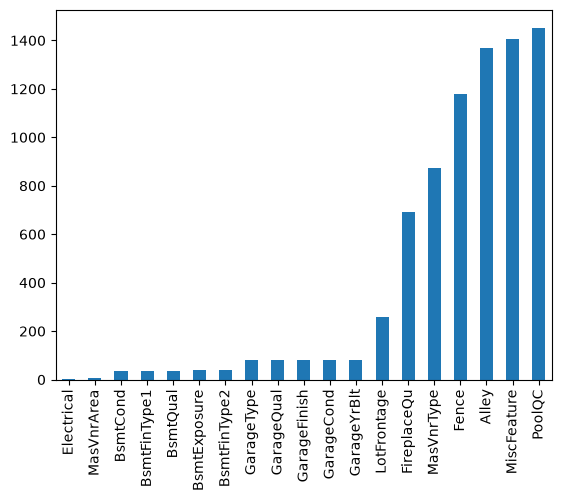

In [22]:
missing = train_df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing.plot.bar()

<Axes: >

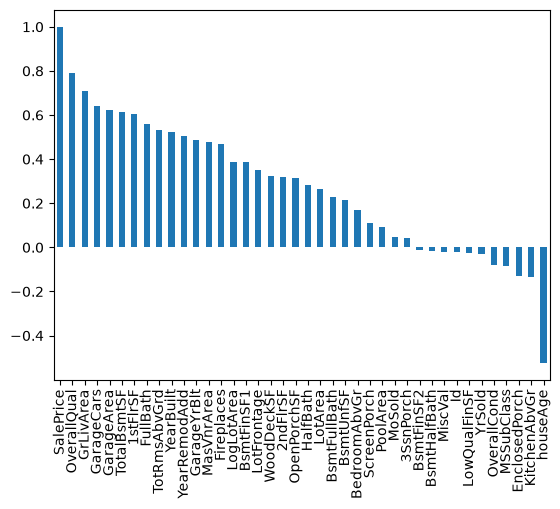

In [24]:
quantitative = train_df.select_dtypes(include='number').columns.tolist()

corr = train_df[quantitative].corr()

saleprice_corr = corr['SalePrice'].sort_values(ascending=False)

saleprice_corr.plot.bar()

In [6]:
train_df['YrSold'].describe()

count    1460.000000
mean     2007.815753
std         1.328095
min      2006.000000
25%      2007.000000
50%      2008.000000
75%      2009.000000
max      2010.000000
Name: YrSold, dtype: float64

# とりあえず
SalePriceの分布を見てみる。
- 平均値 > 中央値で、高価格の住宅が平均を押し上げてるみたい
- 最も多い価格帯は$120k ~ $200kくらい
- $300k, $400k, $700k超えもちらほら

In [7]:
train_df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice', ylabel='Count'>

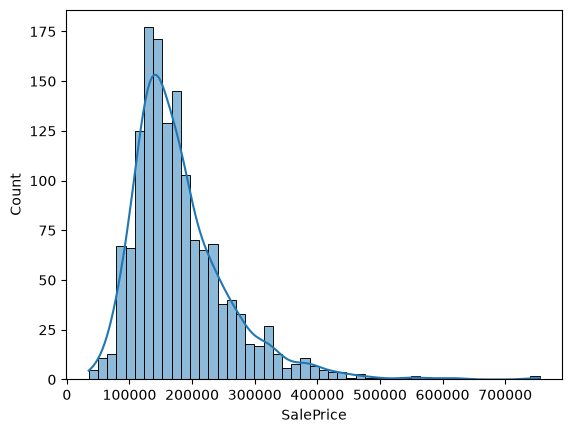

In [8]:
# 右に裾が長い分布（right-skewed）
sns.histplot(train_df['SalePrice'], kde=True)

# 価格と相関のありそうないろいろ
- YearBuilt	建築年
- LotArea	土地面積（平方フィート）
- TotalBsmtSF	地下室の総面積（平方フィート）
- 1stFlrSF	1階の床面積（平方フィート）
- KitchenAbvGr	キッチンの数

In [9]:
cols = [
  'YearBuilt',
  'LotArea',
  'TotalBsmtSF',
  '1stFlrSF',
  'KitchenAbvGr'
]

train_df[cols].isnull().sum()

YearBuilt       0
LotArea         0
TotalBsmtSF     0
1stFlrSF        0
KitchenAbvGr    0
dtype: int64

<Axes: xlabel='houseAge', ylabel='SalePrice'>

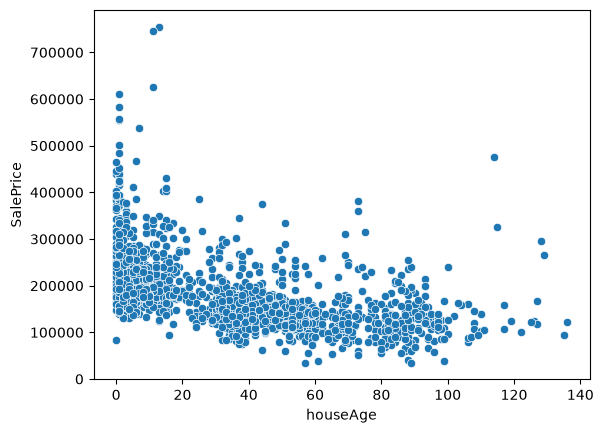

In [18]:
# 価格 × 築年数
train_df['houseAge'] = train_df['YrSold'] - train_df['YearBuilt']

sns.scatterplot(
  data=train_df,
  x='houseAge',
  y='SalePrice',
)

<Axes: xlabel='LogLotArea', ylabel='SalePrice'>

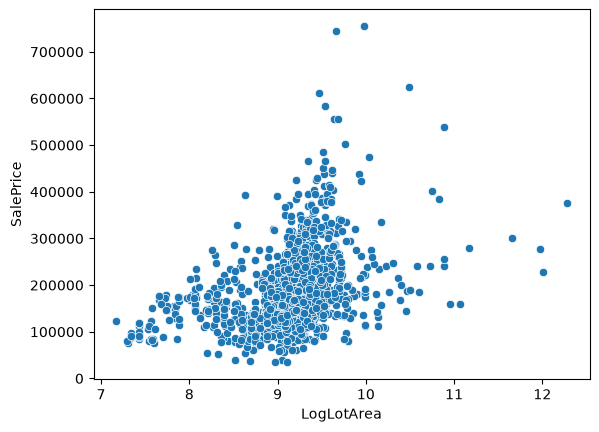

In [20]:
# 価格 × 土地面積
train_df['LogLotArea'] = np.log1p(train_df['LotArea'])

sns.scatterplot(
  data=train_df,
  x='LogLotArea',
  y='SalePrice',
)

# plt.xlim(0, 30000)

In [12]:
train_df['LotArea'].describe()

count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
25%        7553.500000
50%        9478.500000
75%       11601.500000
max      215245.000000
Name: LotArea, dtype: float64

(0.0, 3500.0)

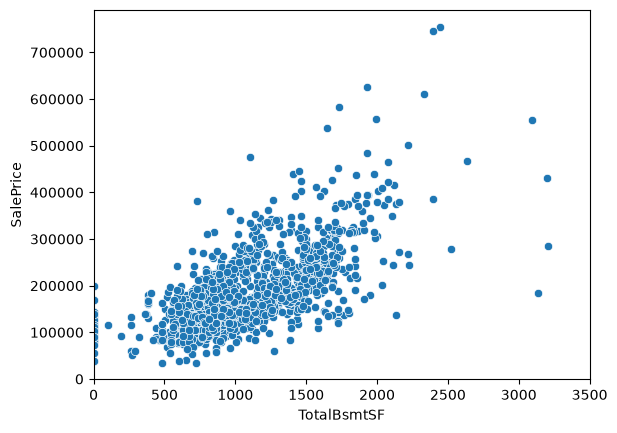

In [13]:
# 価格 × 地下室の総面積
sns.scatterplot(
  data=train_df,
  x='TotalBsmtSF',
  y='SalePrice',
)

plt.xlim(0, 3500)

In [14]:
train_df['TotalBsmtSF'].describe()

count    1460.000000
mean     1057.429452
std       438.705324
min         0.000000
25%       795.750000
50%       991.500000
75%      1298.250000
max      6110.000000
Name: TotalBsmtSF, dtype: float64

<Axes: xlabel='1stFlrSF', ylabel='SalePrice'>

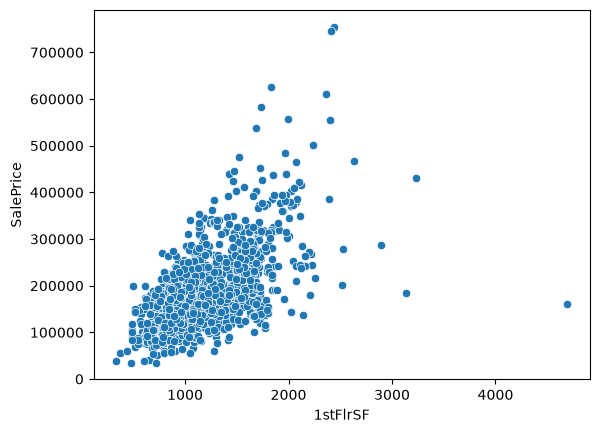

In [15]:
# 価格 × 1階の床面積
sns.scatterplot(
  data=train_df,
  x='1stFlrSF',
  y='SalePrice',
)

In [16]:
train_df['1stFlrSF'].describe()

count    1460.000000
mean     1162.626712
std       386.587738
min       334.000000
25%       882.000000
50%      1087.000000
75%      1391.250000
max      4692.000000
Name: 1stFlrSF, dtype: float64

<Axes: xlabel='KitchenAbvGr', ylabel='SalePrice'>

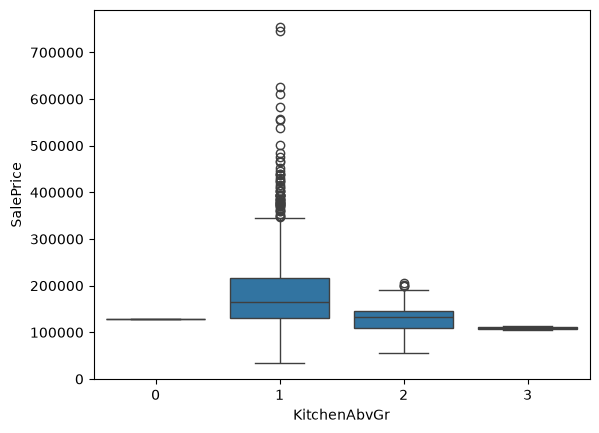

In [17]:
# 価格 × キッチンの数
sns.boxplot(
  data=train_df,
  x='KitchenAbvGr',
  y='SalePrice',
)